In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [15]:
df = pd.read_csv("food_ordering_behavior_dataset.csv")

In [16]:
df

,order_id,user_id,age,city,order_time,day_type,cuisine,meal_type,restaurant_type,order_value,discount_applied,delivery_fee,time_taken_to_order,rating_given,is_repeat_order,mood,hunger_level,company,rainy_weather
0,1,2698,35,Pune,Evening,Weekend,Chinese,Dinner,Premium,971,Yes,90,13,1,Yes,Celebrating,High,Partner,No
1,2,3237,44,Mumbai,Night,Weekend,South Indian,Dinner,Budget,442,No,26,13,2,No,Lazy,Low,Family,No
2,3,3626,31,Delhi,Morning,Weekend,Biryani,Breakfast,Mid-range,739,Yes,85,10,2,Yes,Happy,Medium,Friends,No
3,4,3176,23,Delhi,Evening,Weekend,Biryani,Snacks,Mid-range,466,No,44,12,2,No,Happy,Medium,Alone,No
4,5,4824,26,Chandigarh,Morning,Weekday,Chinese,Lunch,Premium,927,Yes,58,13,2,No,Happy,Medium,Partner,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,3569,40,Hyderabad,Afternoon,Weekday,North Indian,Lunch,Premium,734,Yes,87,6,5,No,Happy,High,Friends,Yes
49996,49997,1087,42,Chandigarh,Morning,Weekend,Fast Food,Lunch,Mid-range,764,Yes,24,14,5,No,Happy,Low,Alone,No
49997,49998,3645,35,Pune,Morning,Weekday,South Indian,Snacks,Budget,985,Yes,53,2,5,Yes,Lazy,Medium,Alone,Yes
49998,49999,3630,34,Delhi,Morning,Weekend,Desserts,Snacks,Premium,860,Yes,48,6,3,Yes,Happy,Low,Alone,Yes


In [17]:
df_editable=df.head(30).iloc[:,:10]

In [18]:
df_editable


,order_id,user_id,age,city,order_time,day_type,cuisine,meal_type,restaurant_type,order_value
0,1,2698,35,Pune,Evening,Weekend,Chinese,Dinner,Premium,971
1,2,3237,44,Mumbai,Night,Weekend,South Indian,Dinner,Budget,442
2,3,3626,31,Delhi,Morning,Weekend,Biryani,Breakfast,Mid-range,739
3,4,3176,23,Delhi,Evening,Weekend,Biryani,Snacks,Mid-range,466
4,5,4824,26,Chandigarh,Morning,Weekday,Chinese,Lunch,Premium,927
5,6,2854,33,Mumbai,Afternoon,Weekend,Biryani,Dinner,Budget,207
6,7,3019,33,Bangalore,Evening,Weekday,Chinese,Lunch,Budget,565
7,8,1505,24,Mumbai,Evening,Weekday,Fast Food,Lunch,Budget,598
8,9,3157,37,Mumbai,Night,Weekend,North Indian,Breakfast,Mid-range,469
9,10,1704,21,Pune,Afternoon,Weekday,Biryani,Dinner,Mid-range,549


In [19]:
#missing variable
df_editable.isnull().sum()

order_id           0
user_id            0
age                0
city               0
order_time         0
day_type           0
cuisine            0
meal_type          0
restaurant_type    0
order_value        0
dtype: int64

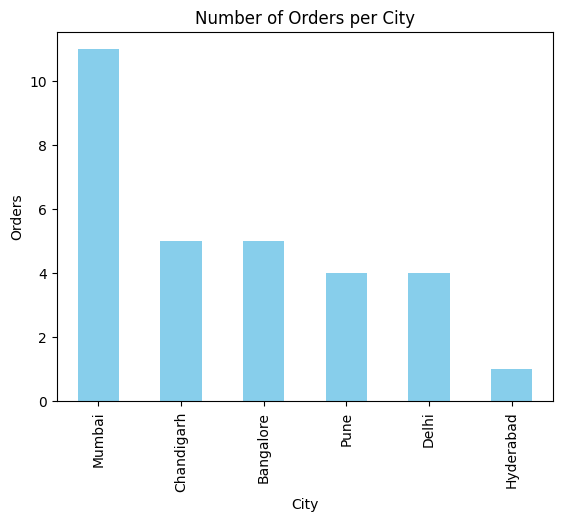

In [20]:
city_counts = df_editable['city'].value_counts()

city_counts.plot(kind='bar', color='skyblue')
plt.title("Number of Orders per City")
plt.xlabel("City")
plt.ylabel("Orders")
plt.show()

In [21]:
df['order_time'] = pd.to_datetime(df['order_time'])
df = df.sort_values('order_time')

plt.plot(df['order_time'], df['order_value'], marker='o')
plt.title("Order Value Over Time")
plt.xlabel("Time")
plt.ylabel("Order Value")
plt.xticks(rotation=45)
plt.show()

C:\Users\lab\AppData\Local\Temp\ipykernel_5648\75930100.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_time'] = pd.to_datetime(df['order_time'])


DateParseError: Unknown datetime string format, unable to parse: Evening

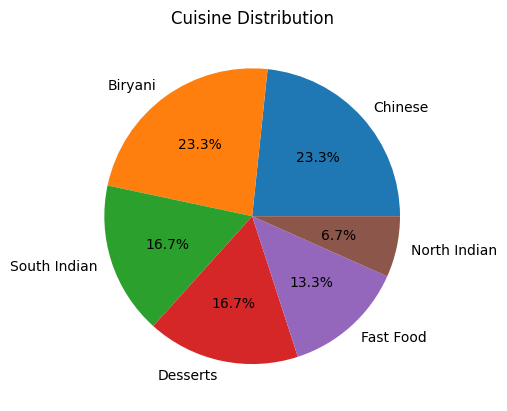

In [22]:
cuisine_counts = df_editable['cuisine'].value_counts()

plt.pie(cuisine_counts, labels=cuisine_counts.index, autopct='%1.1f%%')
plt.title("Cuisine Distribution")
plt.show()

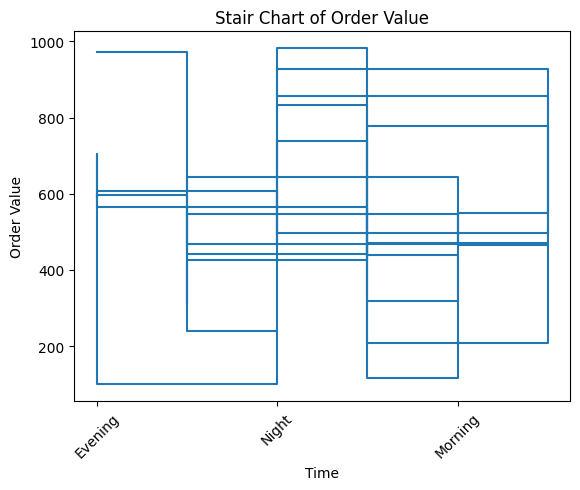

In [23]:
plt.step(df_editable['order_time'], df_editable['order_value'], where='mid')
plt.title("Stair Chart of Order Value")
plt.xlabel("Time")
plt.ylabel("Order Value")
plt.xticks(rotation=45)
plt.show()

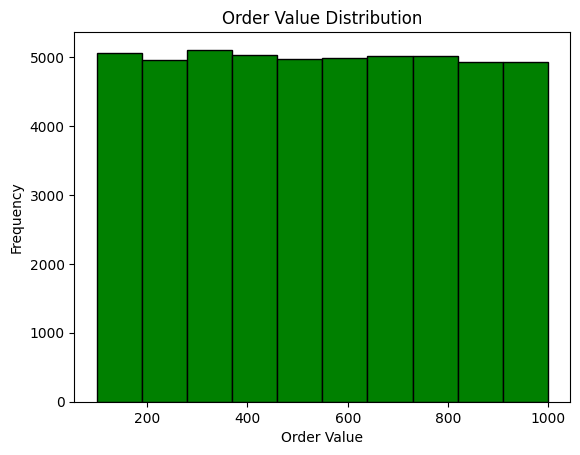

In [ ]:
plt.hist(df_editable['order_value'], bins=10, color='green', edgecolor='black')
plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.show()

In [24]:
df_editable['order_time'] = pd.to_datetime(df_editable['order_time'])

C:\Users\lab\AppData\Local\Temp\ipykernel_5648\3167703449.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_editable['order_time'] = pd.to_datetime(df_editable['order_time'])


DateParseError: Unknown datetime string format, unable to parse: Evening

In [25]:
df_editable['order_time'].head()

0    Evening
1      Night
2    Morning
3    Evening
4    Morning
Name: order_time, dtype: str

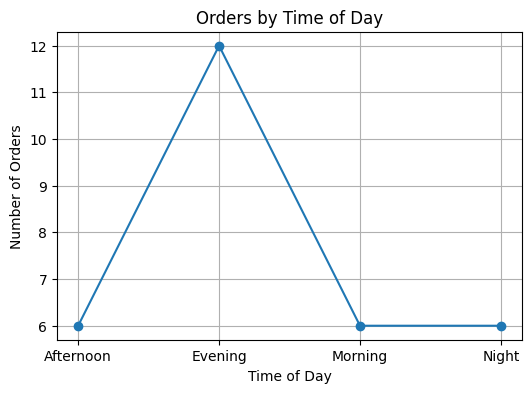

In [26]:
import matplotlib.pyplot as plt

order_counts = df_editable['order_time'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.plot(order_counts.index, order_counts.values, marker='o')
plt.title("Orders by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Orders")
plt.grid(True)
plt.show()

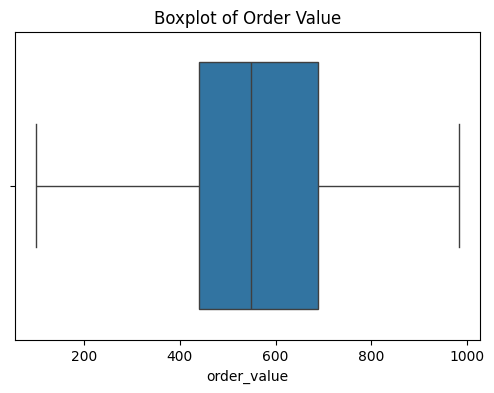

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x=df_editable['order_value'])
plt.title("Boxplot of Order Value")
plt.show()

In [28]:
Q1 = df_editable['order_value'].quantile(0.25)
Q3 = df_editable['order_value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_editable[(df_editable['order_value'] < lower_bound) | (df_editable['order_value'] > upper_bound)]

print("Number of outliers:", len(outliers))
outliers.head()

Number of outliers: 0


,order_id,user_id,age,city,order_time,day_type,cuisine,meal_type,restaurant_type,order_value


In [ ]:
#boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df[['age', 'order_value', 'delivery_fee', 'time_taken_to_order', 'rating_given']])
plt.title("Boxplot of Numerical Features")
plt.show()

NameError: name 'df' is not defined

<Figure size 1000x600 with 0 Axes>

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("food_ordering_behavior_dataset.csv") # replace with your actual file name

In [34]:
df_editable=df.head(30).iloc[:]

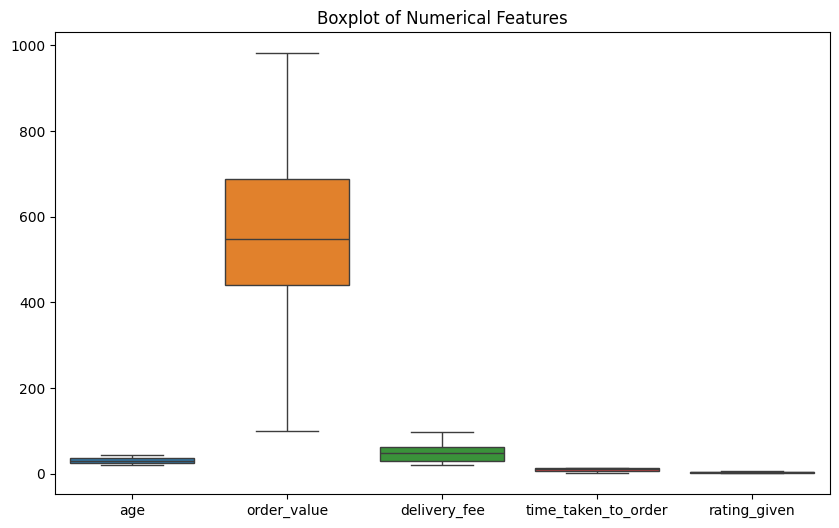

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df_editable[['age', 'order_value', 'delivery_fee', 'time_taken_to_order', 'rating_given']])
plt.title("Boxplot of Numerical Features")
plt.show()

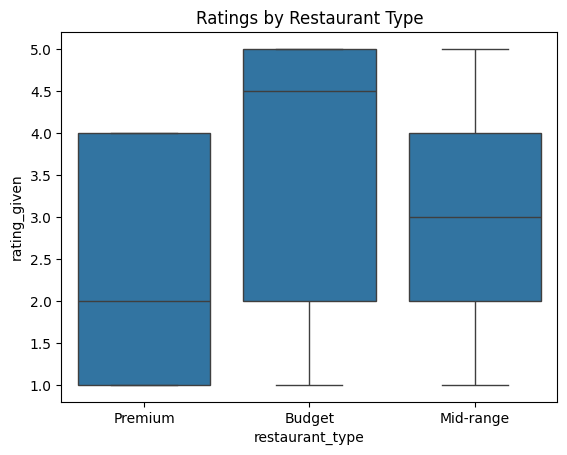

In [36]:
#Rating by Restaurant type
sns.boxplot(x='restaurant_type', y='rating_given', data=df_editable)
plt.title("Ratings by Restaurant Type")
plt.show()

In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   order_id             50000 non-null  int64
 1   user_id              50000 non-null  int64
 2   age                  50000 non-null  int64
 3   city                 50000 non-null  str  
 4   order_time           50000 non-null  str  
 5   day_type             50000 non-null  str  
 6   cuisine              50000 non-null  str  
 7   meal_type            50000 non-null  str  
 8   restaurant_type      50000 non-null  str  
 9   order_value          50000 non-null  int64
 10  discount_applied     50000 non-null  str  
 11  delivery_fee         50000 non-null  int64
 12  time_taken_to_order  50000 non-null  int64
 13  rating_given         50000 non-null  int64
 14  is_repeat_order      50000 non-null  str  
 15  mood                 50000 non-null  str  
 16  hunger_level         50000 non-nu

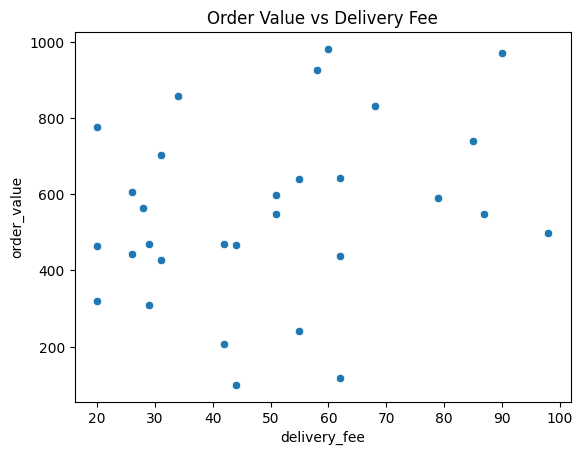

In [37]:
#scatterplot
sns.scatterplot(x='delivery_fee', y='order_value', data=df_editable)
plt.title("Order Value vs Delivery Fee")
plt.show()

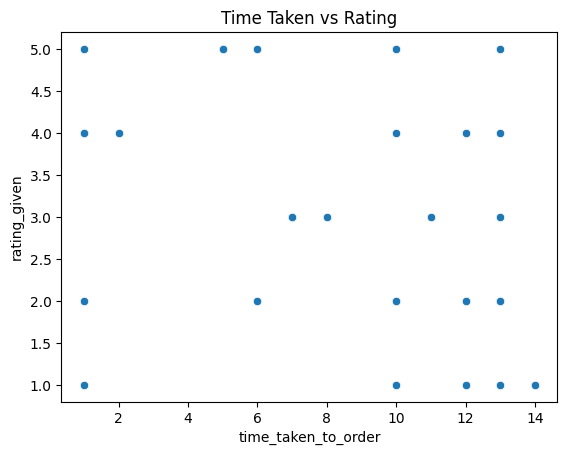

In [38]:
sns.scatterplot(x='time_taken_to_order', y='rating_given', data=df_editable)
plt.title("Time Taken vs Rating")
plt.show()

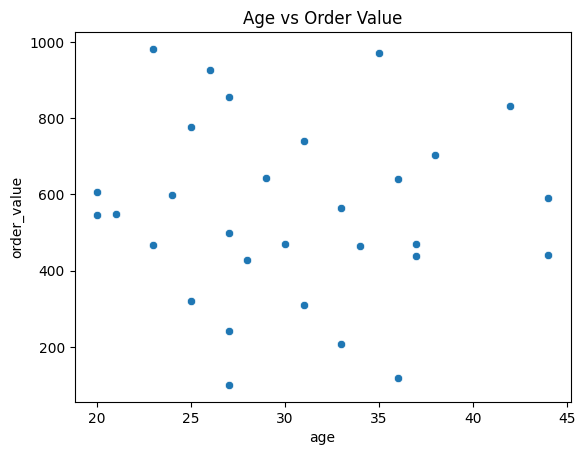

In [39]:
sns.scatterplot(x='age', y='order_value', data=df_editable)
plt.title("Age vs Order Value")
plt.show()

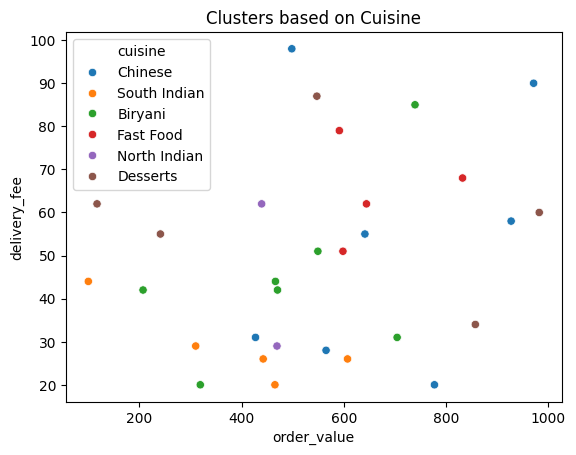

In [40]:
sns.scatterplot(x='order_value', y='delivery_fee', hue='cuisine', data=df_editable)
plt.title("Clusters based on Cuisine")
plt.show()

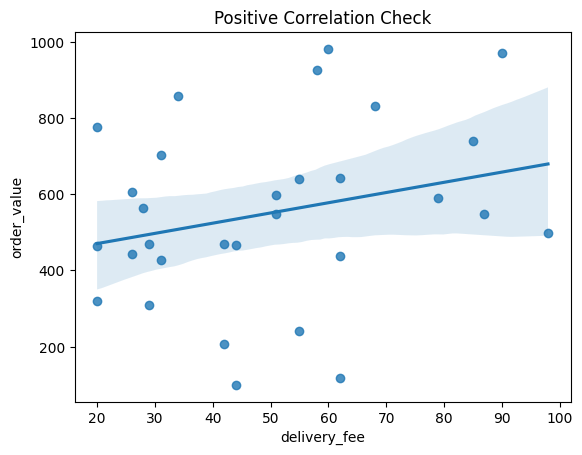

In [41]:
sns.regplot(x='delivery_fee', y='order_value', data=df_editable)
plt.title("Positive Correlation Check")
plt.show()

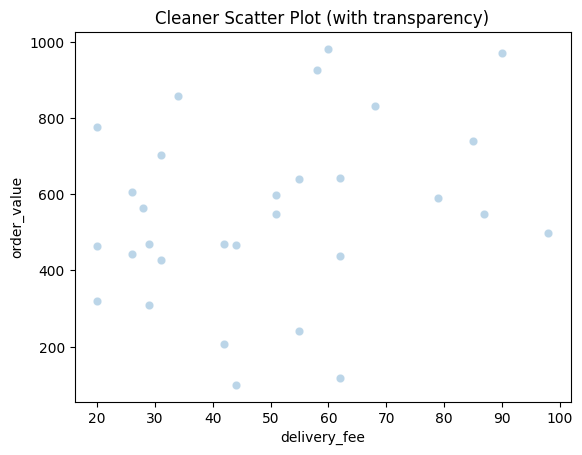

In [42]:
sns.scatterplot(x='delivery_fee', y='order_value', data=df_editable, alpha=0.3)
plt.title("Cleaner Scatter Plot (with transparency)")
plt.show()

In [ ]:
print("Hello")

Hello
